<a href="https://colab.research.google.com/github/ThiagoDamasz/capacitacao-IA-CS-I/blob/main/Aprendizado_por_Refor%C3%A7o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np

## Definindo a função do Grid

Aqui definimos o nosso ambiente. O tamanho da matriz que o robô vai percorrer, as opções de caminho que ele tem e os obstáculos. Além disso também definimos funções para o robô recomeçar o percurso, andar e um caminho visual por onde ele passa.


In [10]:
class GridWorld:
    def __init__(self):
        self.grid_size = 10 #tamanho da matriz
        self.start_pos = (0, 0) # ínicio do robo
        self.goal_pos = (9, 9) # Chegada da matriz
        self.holes_pos = [
            (1, 1), (1, 2), (1, 3),
            (4, 4), (4, 5), (5, 4),
            (7, 8), (8, 7), (8, 8)
        ] #obstáculos
        self.state = self.start_pos

        # Ações: 0=Cima, 1=Baixo, 2=Esquerda, 3=Direita
        self.action_space = [0, 1, 2, 3]

    def reset(self):
        """Reinicia o robô para a posição inicial."""
        self.state = self.start_pos
        return self.state

    def step(self, action):
        """Executa uma ação e retorna: (novo_estado, recompensa, fim)"""
        r, c = self.state # posicao inicial do robô. (r,c/linha,coluna)

        if action == 0:   # Cima subtrai 1 da linha
            r = max(0, r - 1)
        elif action == 1: # Baixo soma 1 da linha
            r = min(self.grid_size - 1, r + 1)
        elif action == 2: # Esquerda subtrai 1 da culuna
            c = max(0, c - 1)
        elif action == 3: # Direita  soma 1 da coluna
            c = min(self.grid_size - 1, c + 1)

        self.state = (r, c)

        # Verificação de Recompensas e Fim de Jogo
        if self.state == self.goal_pos:
            return self.state, 10, True  # Vitória!
        elif self.state in self.holes_pos:
            return self.state, -10, True # Derrota!
        else:
            return self.state, -1, False  # Custo do movimento

    def render(self):
        """Desenha o grid no terminal para visualizarmos o robô."""
        grid = np.full((self.grid_size, self.grid_size), ".")
        grid[self.hole_pos] = "X" # Buraco
        grid[self.goal_pos] = "O" # Objetivo
        grid[self.state] = "R"    # Robô

        for row in grid:
            print(" ".join(row))
        print("-" * 10)

# O cérebro do robô

Abaixo temos a classe QLearningAgent, ela é a representação do cérebro do nosso robô.Em Aprendizado por Reforço, o Agente é a entidade que interage com o ambiente, toma decisões, aprende com as consequências (recompensas ou punições) e tenta descobrir a melhor estratégia possível para resolver o problema.

Como não estamos usando redes neurais, aqui temos um agente tabular. Ou seja uma grande tabela (Q-table) para anotar o quanto vale a pena tomar cada ação em cada quadrado do mapa.

## Os parâmetros

- num_actions

O número de ações possíveis no ambiente.

Está definido como 4 (Cima, Baixo, Esquerda e Direita). Ele serve para sabermos quantas colunas a nossa Q-Table precisará ter.

- alpha

Controla a velocidade com que o robô substitui o conhecimento antigo por informações novas que acabou de vivenciar. Geralmente utiliza-se valores baixos, entre 0.01 e 0.1.

Se o $\alpha$ for muito alto (perto de 1.0): O robô se torna "esquecido". Ele foca apenas na última recompensa recebida e desconsidera todo o histórico do que aprendeu no passado.

Se o $\alpha$ for muito baixo (perto de 0.0): O robô se torna "turrão". Ele demora muito para evoluir porque altera os valores armazenados na tabela de forma extremamente lenta.

- gamma

Define o peso que o robô da para as recompensas futuras em comparação com as recompensas imediatas. Varia entre 0 e 1. Quanto mais próximo de 0, menos "a frente" o robô vai pensar.

Ex:
O robô escolhe sempre um caminho sem penalidades para dar o próximo passo.
Se o gamma estiver mais próximo de 1, o robô analisa não só o próximo passo mas também o final. Isso significa que ele pode escolher o próximo caminho que tem uma penalidade, mas o melhor caminho no final.

- epsilon

A probabilidade inicial de o robô tomar uma decisão de forma 100% aleatória, em vez de consultar a tabela.

Como a Q-Table nasce completamente zerada, o robô não tem nenhuma informação útil guardada. Começar com o epsilon no valor máximo força o agente a explorar o mapa de forma descompromissada (como um "bêbado" andando pelo grid) para mapear onde estão os perigos e os prêmios.


In [7]:
import random

class QLearningAgent:
    def __init__(self, num_states=100, num_actions=4, alpha=0.1, gamma=0.99, epsilon=1.0, max_epsilon=1.0, min_epsilon=0.01, decay_rate=0.005):
        self.num_actions = num_actions
        self.alpha = alpha          # Taxa de aprendizado (o quão rápido ele aceita novas informações)
        self.gamma = gamma          # Fator de desconto (o quanto ele valoriza recompensas futuras)
        self.epsilon = epsilon      # Taxa de exploração inicial
        self.min_epsilon = min_epsilon
        self.decay_rate = decay_rate

        # Inicializa a Q-Table com zeros (100 estados x 4 ações)
        self.q_table = np.zeros((num_states, num_actions))

    def state_to_index(self, state):
        """Converte a coordenada (linha, coluna) em um índice único de 0 a 99."""
        return state[0] * 10 + state[1]

    def choose_action(self, state):
        """Escolhe uma ação usando a estratégia Epsilon-Greedy."""
        state_idx = self.state_to_index(state)

        # Exploração: Escolhe uma ação aleatória
        if random.uniform(0, 1) < self.epsilon:
            return random.choice([0, 1, 2, 3])
        # Explotação: Escolhe a melhor ação da Q-Table para aquele estado
        else:
            return np.argmax(self.q_table[state_idx])

    def update_q_table(self, state, action, reward, next_state):
        """A Equação de Bellman aplicada na prática."""
        state_idx = self.state_to_index(state)
        next_state_idx = self.state_to_index(next_state)

        # Maior valor Q estimado para o próximo estado
        max_future_q = np.max(self.q_table[next_state_idx])

        # Valor Q atual para a ação tomada
        current_q = self.q_table[state_idx, action]

        # Aplicação da fórmula
        new_q = current_q + self.alpha * (reward + self.gamma * max_future_q - current_q)
        self.q_table[state_idx, action] = new_q

    def decay_epsilon(self, episode):
        self.epsilon = self.min_epsilon + (1.0 - self.min_epsilon) * np.exp(-self.decay_rate * episode)



# Treinamento

Aqui colocamos todas as funções que criamos em prática, começando o treinamento do robô.

Também salvamos o desempenho. do treinamentos em listas, para analisarmos depois.

In [15]:
env = GridWorld()
agent = QLearningAgent()

num_episodes = 2000

# Listas para guardar o desempenho
historico_recompensas = []
historico_passos = []

print("A treinar o robô e a recolher dados de desempenho...")
for episode in range(num_episodes):
    state = env.reset()
    done = False

    recompensa_acumulada = 0
    passos_no_episodio = 0

    while not done:
        action = agent.choose_action(state)
        next_state, reward, done = env.step(action)
        agent.update_q_table(state, action, reward, next_state)

        recompensa_acumulada += reward
        passos_no_episodio += 1
        state = next_state

    agent.decay_epsilon(episode)

    # Guardar as métricas deste episódio
    historico_recompensas.append(recompensa_acumulada)
    historico_passos.append(passos_no_episodio)

print("Treino concluído!")

A treinar o robô e a recolher dados de desempenho...
Treino concluído!


# Teste

Nesta fase vamos ver os resultados do treinamento e verificar se foi treinado corretamente. Também veremos se a quantidade de episódios, isso é de vezes que o robô percorreu a matriz, está adequada.

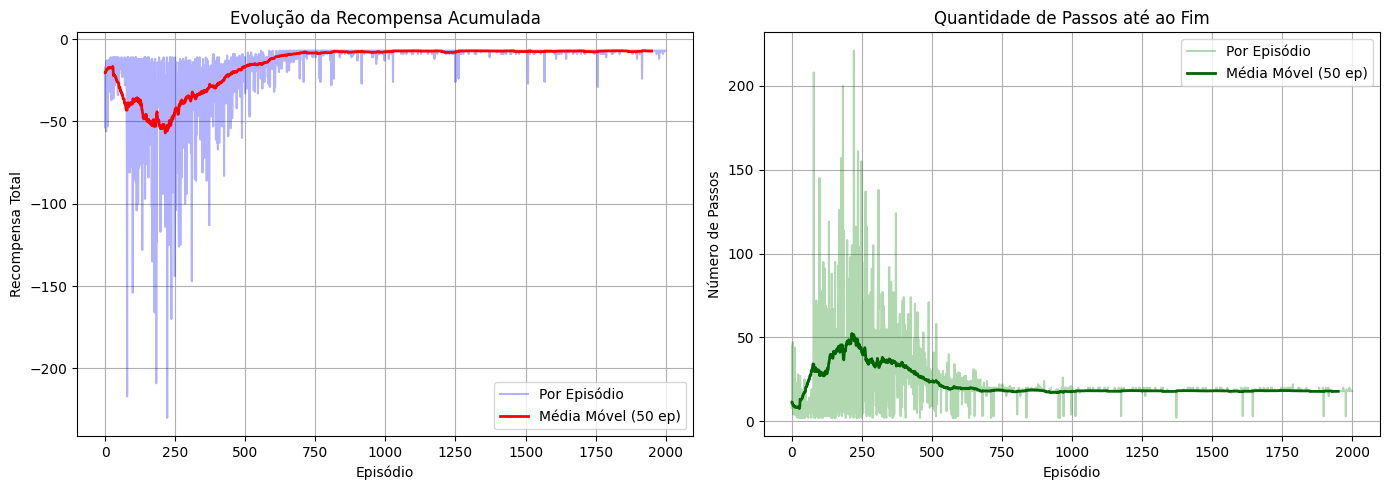

In [17]:
import matplotlib.pyplot as plt
# 4. PLOTAR OS GRÁFICOS DE DESEMPENHO
# ==========================================
plt.figure(figsize=(14, 5))

# Gráfico 1: Recompensas Acumuladas
plt.subplot(1, 2, 1)
plt.plot(historico_recompensas, color='blue', alpha=0.3, label='Por Episódio')
# Linha de média móvel para suavizar o gráfico e ver a tendência clara
medias_moveis_rec = np.convolve(historico_recompensas, np.ones(50)/50, mode='valid')
plt.plot(medias_moveis_rec, color='red', linewidth=2, label='Média Móvel (50 ep)')
plt.title('Evolução da Recompensa Acumulada')
plt.xlabel('Episódio')
plt.ylabel('Recompensa Total')
plt.legend()
plt.grid(True)

# Gráfico 2: Quantidade de Passos
plt.subplot(1, 2, 2)
plt.plot(historico_passos, color='green', alpha=0.3, label='Por Episódio')
medias_moveis_passos = np.convolve(historico_passos, np.ones(50)/50, mode='valid')
plt.plot(medias_moveis_passos, color='darkgreen', linewidth=2, label='Média Móvel (50 ep)')
plt.title('Quantidade de Passos até ao Fim')
plt.xlabel('Episódio')
plt.ylabel('Número de Passos')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Então treinamos o robô com 2000 episódios, percorrendo uma matriz 10x10 até chegar na última linha da última coluna. Percebemos que pelos gráficos as recompensas geradas aumentam e depois diminuem até se estabilizar.

Isso significa que o robô aprendeu enquanto as recompensas aumentavam, e quando as recompensas se estabilizaram ele já sabia o caminho que deveria percorrer.

2000 Episódios foi muito mais que o necessário para o robô aprender. Pelo gráfico o ideal é de 750 a 900 episódios.

O mesmo vale para a quantidade de passos que o robô deu.